# Solvent Accessibility Analysis (SASA & RSA) for PDB Structures

This notebook calculates Solvent Accessible Surface Area (SASA) and Relative Solvent Accessibility (RSA) for all sites in PDB files, both with and without antigen present.

Adapted from Dave's code: dnsm-experiments-1/dnsmex/dms_viz.py

In [22]:
import os
import random
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm

# BioPython imports for PDB handling and DSSP
from Bio.PDB import PDBParser, PDBIO, Select
from Bio.PDB.DSSP import DSSP
from Bio import PDB
from Bio.SeqUtils import seq1

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

from utils import add_germline_information


# Display settings
#pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', 20)


## Analysis and Visualization Functions

In [ ]:
# using data from run_sasa_analysis.py
#df = pd.read_csv('_output/sasa_results.csv')
df = pd.read_csv('_output/sasa_test_results.csv')

# As we use a public pdb database, some structures may not have the antigen bound. Let's filter those out.
df[~df.antigen_chains.isna()]
#### MAKE SURE THIS WORKS, OTHERWISE USE NA FILTER

# let's also focus on heavy chain and only human samples
df = df[(df.chain_id == df.heavy_chain_id) & (df.organism == 'human_ig')]

# focus only on residues of variable region
df = df[(df.residue_number <= 129) & (df.residue_number > 0)]

df

,pdb_id,organism,v_gene_light,j_gene_light,v_gene_heavy,j_gene_heavy,heavy_chain_id,light_chain_id,antigen_chains,chain_id,...,rsa_heavy_only,sasa_antigen_effect,rsa_antigen_effect,sasa_antigen_relative,rsa_antigen_relative,sasa_light_effect,rsa_light_effect,sasa_light_relative,rsa_light_relative,ca_coordinates
226,8hpf,human_ig,IGKV1D-39*01,IGKJ4*01,IGHV3-66*01,IGHJ3*02,M,N,A,M,...,0.425287,-23.0,-0.132184,-0.310811,-0.310811,0.0,0.0,0.0,0.0,"(np.float32(193.448), np.float32(197.673), np...."
227,8hpf,human_ig,IGKV1D-39*01,IGKJ4*01,IGHV3-66*01,IGHJ3*02,M,N,A,M,...,0.528889,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(196.442), np.float32(199.779), np...."
228,8hpf,human_ig,IGKV1D-39*01,IGKJ4*01,IGHV3-66*01,IGHJ3*02,M,N,A,M,...,0.024876,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(199.674), np.float32(200.308), np...."
229,8hpf,human_ig,IGKV1D-39*01,IGKJ4*01,IGHV3-66*01,IGHJ3*02,M,N,A,M,...,0.350575,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(201.856), np.float32(202.94), np.f..."
230,8hpf,human_ig,IGKV1D-39*01,IGKJ4*01,IGHV3-66*01,IGHJ3*02,M,N,A,M,...,0.026906,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(205.475), np.float32(203.15), np.f..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12946,7tow,human_ig,IGKV1-9*01,IGKJ5*01,IGHV3-30-5*01,IGHJ6*01,A,B,D,A,...,0.116279,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(-24.636), np.float32(27.431), np.f..."
12947,7tow,human_ig,IGKV1-9*01,IGKJ5*01,IGHV3-30-5*01,IGHJ6*01,A,B,D,A,...,0.045977,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(-27.167), np.float32(28.186), np.f..."
12948,7tow,human_ig,IGKV1-9*01,IGKJ5*01,IGHV3-30-5*01,IGHJ6*01,A,B,D,A,...,0.154839,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(-30.377), np.float32(29.097), np.f..."
12949,7tow,human_ig,IGKV1-9*01,IGKJ5*01,IGHV3-30-5*01,IGHJ6*01,A,B,D,A,...,0.490323,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(-34.118), np.float32(28.41), np.fl..."


In [93]:

germline = pd.read_csv('germline/germline_codons.csv')

# we can merge directly as this is only heavy chain
df = pd.merge(df,germline.rename(columns={'v_gene':'v_gene_heavy','site':'residue_number', 'amino_acid':'germline_amino_acid', 'v_family':'v_family_heavy'}).drop(columns=['codon']), on=['v_gene_heavy', 'residue_number'], how='left')

df['is_germline'] = np.where(
    df['germline_amino_acid'].isna(),
    np.nan,
    df['amino_acid'] == df['germline_amino_acid']
)


df['v_family_heavy'] = df.v_gene_heavy.str.extract(r'(IGHV\d+)', expand=False)

In [94]:
df

,pdb_id,organism,v_gene_light,j_gene_light,v_gene_heavy,j_gene_heavy,heavy_chain_id,light_chain_id,antigen_chains,chain_id,...,sasa_antigen_relative,rsa_antigen_relative,sasa_light_effect,rsa_light_effect,sasa_light_relative,rsa_light_relative,ca_coordinates,v_family_heavy,germline_amino_acid,is_germline
0,8hpf,human_ig,IGKV1D-39*01,IGKJ4*01,IGHV3-66*01,IGHJ3*02,M,N,A,M,...,-0.310811,-0.310811,0.0,0.0,0.0,0.0,"(np.float32(193.448), np.float32(197.673), np....",IGHV3,V,1.0
1,8hpf,human_ig,IGKV1D-39*01,IGKJ4*01,IGHV3-66*01,IGHJ3*02,M,N,A,M,...,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(196.442), np.float32(199.779), np....",IGHV3,Q,1.0
2,8hpf,human_ig,IGKV1D-39*01,IGKJ4*01,IGHV3-66*01,IGHJ3*02,M,N,A,M,...,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(199.674), np.float32(200.308), np....",IGHV3,L,1.0
3,8hpf,human_ig,IGKV1D-39*01,IGKJ4*01,IGHV3-66*01,IGHJ3*02,M,N,A,M,...,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(201.856), np.float32(202.94), np.f...",IGHV3,V,1.0
4,8hpf,human_ig,IGKV1D-39*01,IGKJ4*01,IGHV3-66*01,IGHJ3*02,M,N,A,M,...,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(205.475), np.float32(203.15), np.f...",IGHV3,E,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1827,7tow,human_ig,IGKV1-9*01,IGKJ5*01,IGHV3-30-5*01,IGHJ6*01,A,B,D,A,...,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(-24.636), np.float32(27.431), np.f...",IGHV3,NaN,NaN
1828,7tow,human_ig,IGKV1-9*01,IGKJ5*01,IGHV3-30-5*01,IGHJ6*01,A,B,D,A,...,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(-27.167), np.float32(28.186), np.f...",IGHV3,NaN,NaN
1829,7tow,human_ig,IGKV1-9*01,IGKJ5*01,IGHV3-30-5*01,IGHJ6*01,A,B,D,A,...,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(-30.377), np.float32(29.097), np.f...",IGHV3,NaN,NaN
1830,7tow,human_ig,IGKV1-9*01,IGKJ5*01,IGHV3-30-5*01,IGHJ6*01,A,B,D,A,...,0.000000,0.000000,0.0,0.0,0.0,0.0,"(np.float32(-34.118), np.float32(28.41), np.fl...",IGHV3,NaN,NaN


<Axes: xlabel='residue_number', ylabel='count'>

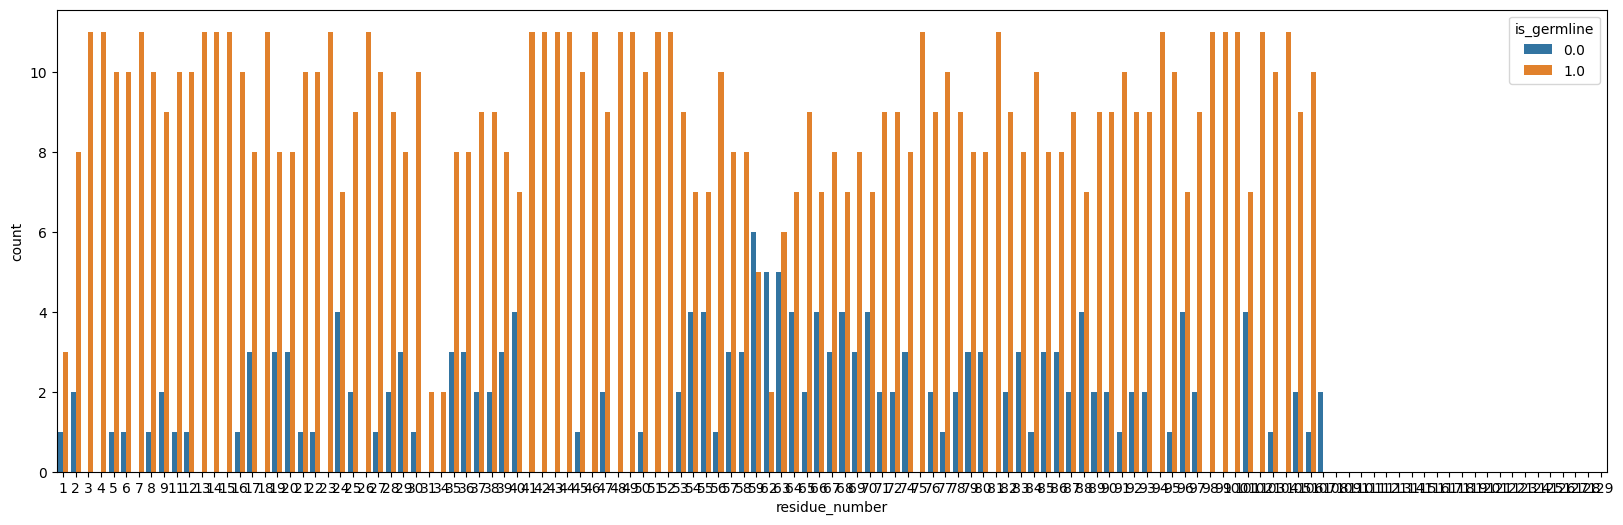

In [95]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.countplot(df, x='residue_number', hue='is_germline', ax=ax)

In [96]:
CDRS = list(range(27,39)) + list(range(56,66)) + list(range(105,117))

df['is_cdr'] = df.residue_number.isin(CDRS)

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122],
 [Text(0, 0, '1'),
  Text(1, 0, '2'),
  Text(2, 0, '3'),
  Text(3, 0, '4'),
  Text(4, 0, '5'),
  Text(5, 0, '6'),
  Text(6, 0, '7'),
  Text(7, 0, '8'),
  Text(8, 0, '9'),
  Text(9, 0, '11'),
  Text(10, 0, '12'),
  Text(11, 0, '13'),
  Text(12, 0, '

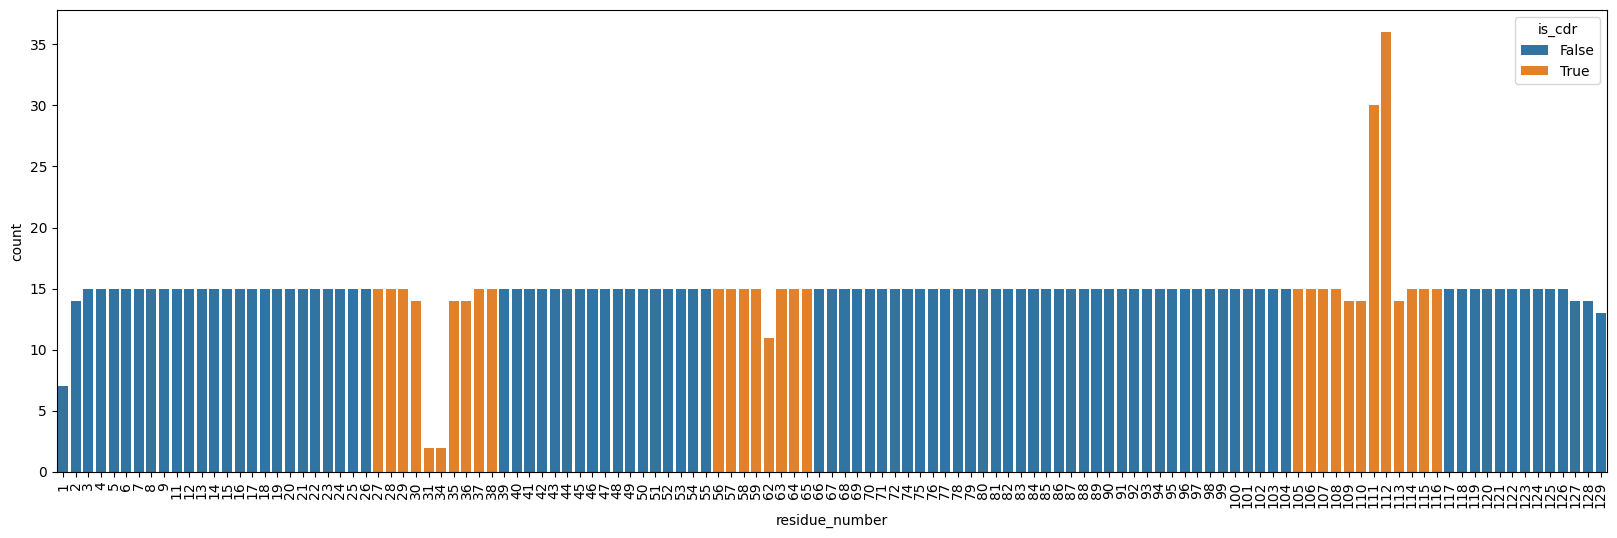

In [97]:
fig, ax = plt.subplots(figsize=(20, 6))
#sns.countplot(df[(df.chain_id == 'H') & (df.residue_number <= 129)], x='residue_number',ax=ax)
sns.countplot(df, x='residue_number',ax=ax, hue='is_cdr')

# rotate x labels for better readability
plt.xticks(rotation=90)


In [98]:
df[(df.residue_number == 34)]

,pdb_id,organism,v_gene_light,j_gene_light,v_gene_heavy,j_gene_heavy,heavy_chain_id,light_chain_id,antigen_chains,chain_id,...,rsa_antigen_relative,sasa_light_effect,rsa_light_effect,sasa_light_relative,rsa_light_relative,ca_coordinates,v_family_heavy,germline_amino_acid,is_germline,is_cdr
271,7d0d,human_ig,IGKV4-1*01,IGKJ2*02,IGHV2-5*02,IGHJ4*01,G,F,B,G,...,0.0,0.0,0.0,0.0,0.0,"(np.float32(183.164), np.float32(165.897), np....",IGHV2,T,1.0,True
631,3l5y,human_ig,IGKV3-11*01,IGKJ2*01,IGHV2-5*02,IGHJ4*01,H,L,A,H,...,0.0,0.0,0.0,0.0,0.0,"(np.float32(0.978), np.float32(33.33), np.floa...",IGHV2,T,1.0,True


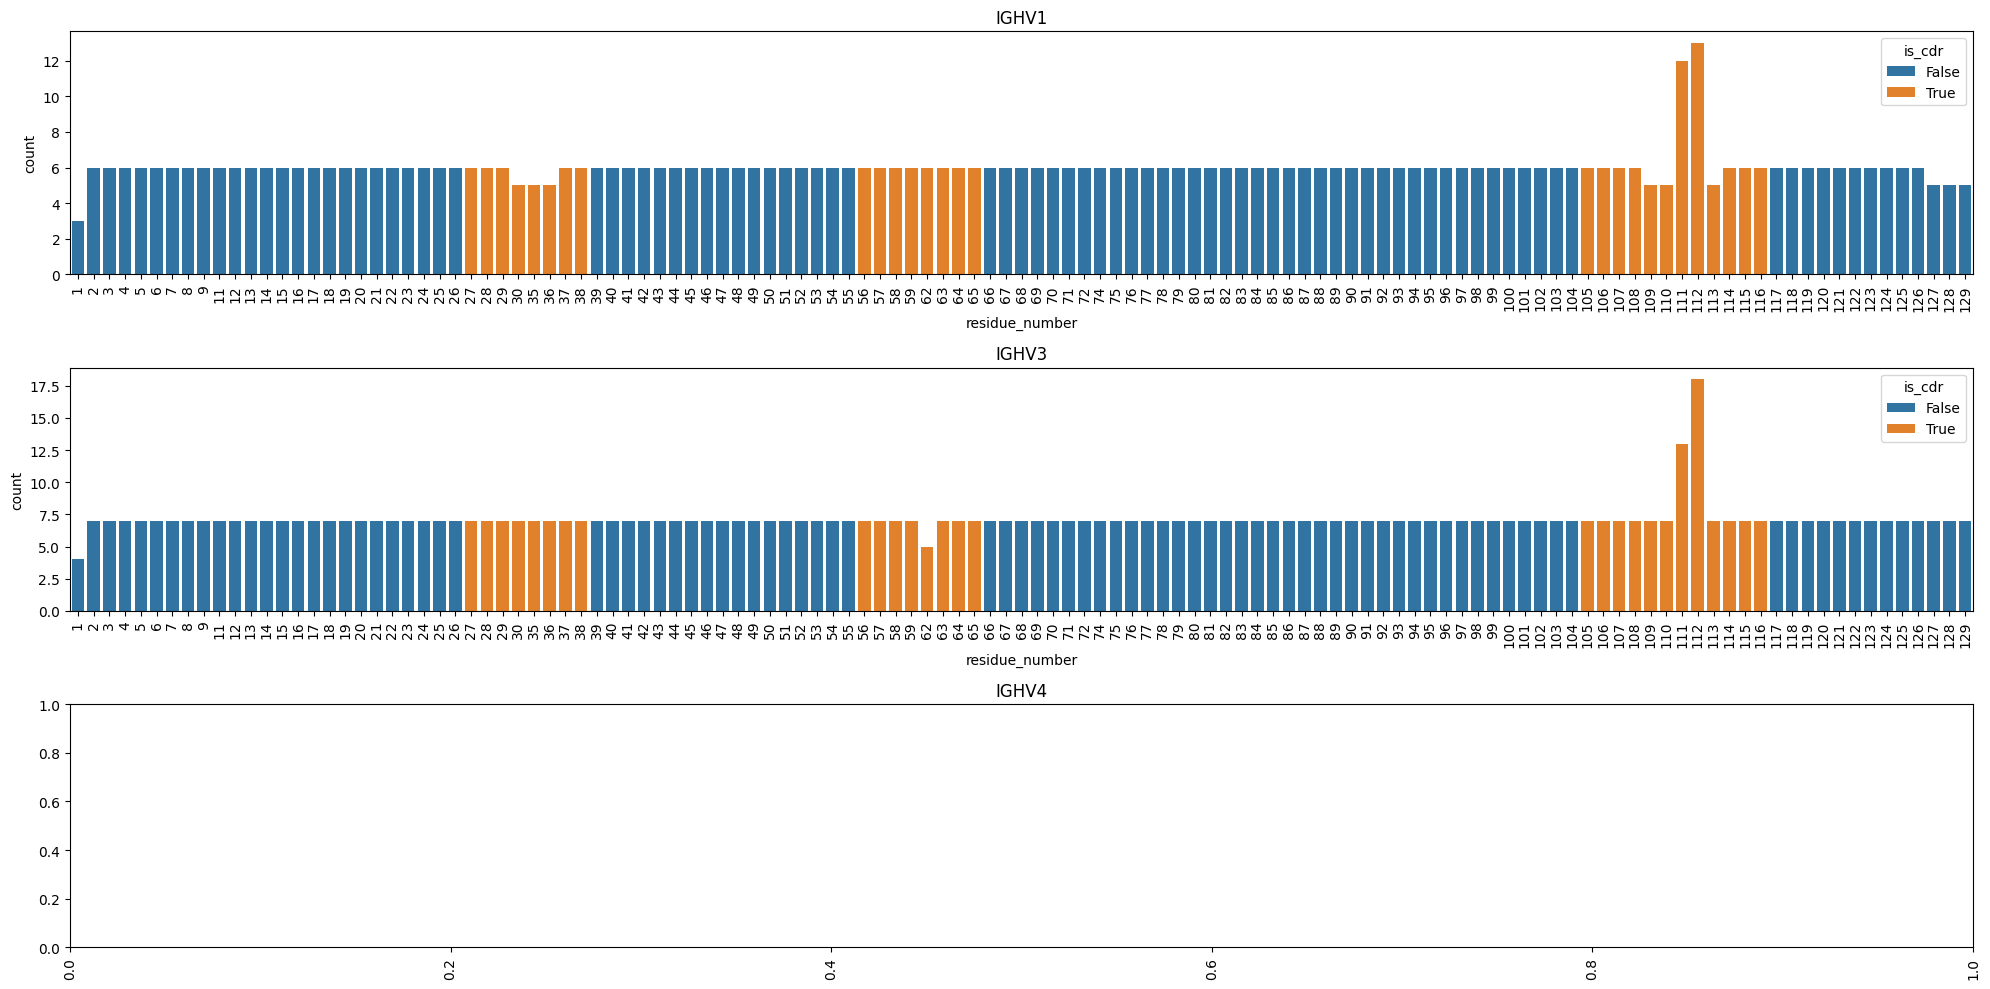

In [99]:
fig, axes = plt.subplots(3, 1, figsize=(20, 10))

# Define the gene types you want to plot
v_families = ['IGHV1', 'IGHV3', 'IGHV4']

for i, gene_type in enumerate(v_families):
    # Filter data for each gene type
    filtered_data = df[(df.v_family_heavy == gene_type)]
    
    # Create countplot for each subplot
    sns.countplot(data=filtered_data, x='residue_number', ax=axes[i], hue='is_cdr')
    
    # Set title for each subplot
    axes[i].set_title(f'{gene_type}')
    
    # Rotate x labels for better readability
    axes[i].tick_params(axis='x', rotation=90)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [100]:
df

,pdb_id,organism,v_gene_light,j_gene_light,v_gene_heavy,j_gene_heavy,heavy_chain_id,light_chain_id,antigen_chains,chain_id,...,rsa_antigen_relative,sasa_light_effect,rsa_light_effect,sasa_light_relative,rsa_light_relative,ca_coordinates,v_family_heavy,germline_amino_acid,is_germline,is_cdr
0,8hpf,human_ig,IGKV1D-39*01,IGKJ4*01,IGHV3-66*01,IGHJ3*02,M,N,A,M,...,-0.310811,0.0,0.0,0.0,0.0,"(np.float32(193.448), np.float32(197.673), np....",IGHV3,V,1.0,False
1,8hpf,human_ig,IGKV1D-39*01,IGKJ4*01,IGHV3-66*01,IGHJ3*02,M,N,A,M,...,0.000000,0.0,0.0,0.0,0.0,"(np.float32(196.442), np.float32(199.779), np....",IGHV3,Q,1.0,False
2,8hpf,human_ig,IGKV1D-39*01,IGKJ4*01,IGHV3-66*01,IGHJ3*02,M,N,A,M,...,0.000000,0.0,0.0,0.0,0.0,"(np.float32(199.674), np.float32(200.308), np....",IGHV3,L,1.0,False
3,8hpf,human_ig,IGKV1D-39*01,IGKJ4*01,IGHV3-66*01,IGHJ3*02,M,N,A,M,...,0.000000,0.0,0.0,0.0,0.0,"(np.float32(201.856), np.float32(202.94), np.f...",IGHV3,V,1.0,False
4,8hpf,human_ig,IGKV1D-39*01,IGKJ4*01,IGHV3-66*01,IGHJ3*02,M,N,A,M,...,0.000000,0.0,0.0,0.0,0.0,"(np.float32(205.475), np.float32(203.15), np.f...",IGHV3,E,1.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1827,7tow,human_ig,IGKV1-9*01,IGKJ5*01,IGHV3-30-5*01,IGHJ6*01,A,B,D,A,...,0.000000,0.0,0.0,0.0,0.0,"(np.float32(-24.636), np.float32(27.431), np.f...",IGHV3,NaN,NaN,False
1828,7tow,human_ig,IGKV1-9*01,IGKJ5*01,IGHV3-30-5*01,IGHJ6*01,A,B,D,A,...,0.000000,0.0,0.0,0.0,0.0,"(np.float32(-27.167), np.float32(28.186), np.f...",IGHV3,NaN,NaN,False
1829,7tow,human_ig,IGKV1-9*01,IGKJ5*01,IGHV3-30-5*01,IGHJ6*01,A,B,D,A,...,0.000000,0.0,0.0,0.0,0.0,"(np.float32(-30.377), np.float32(29.097), np.f...",IGHV3,NaN,NaN,False
1830,7tow,human_ig,IGKV1-9*01,IGKJ5*01,IGHV3-30-5*01,IGHJ6*01,A,B,D,A,...,0.000000,0.0,0.0,0.0,0.0,"(np.float32(-34.118), np.float32(28.41), np.fl...",IGHV3,NaN,NaN,False


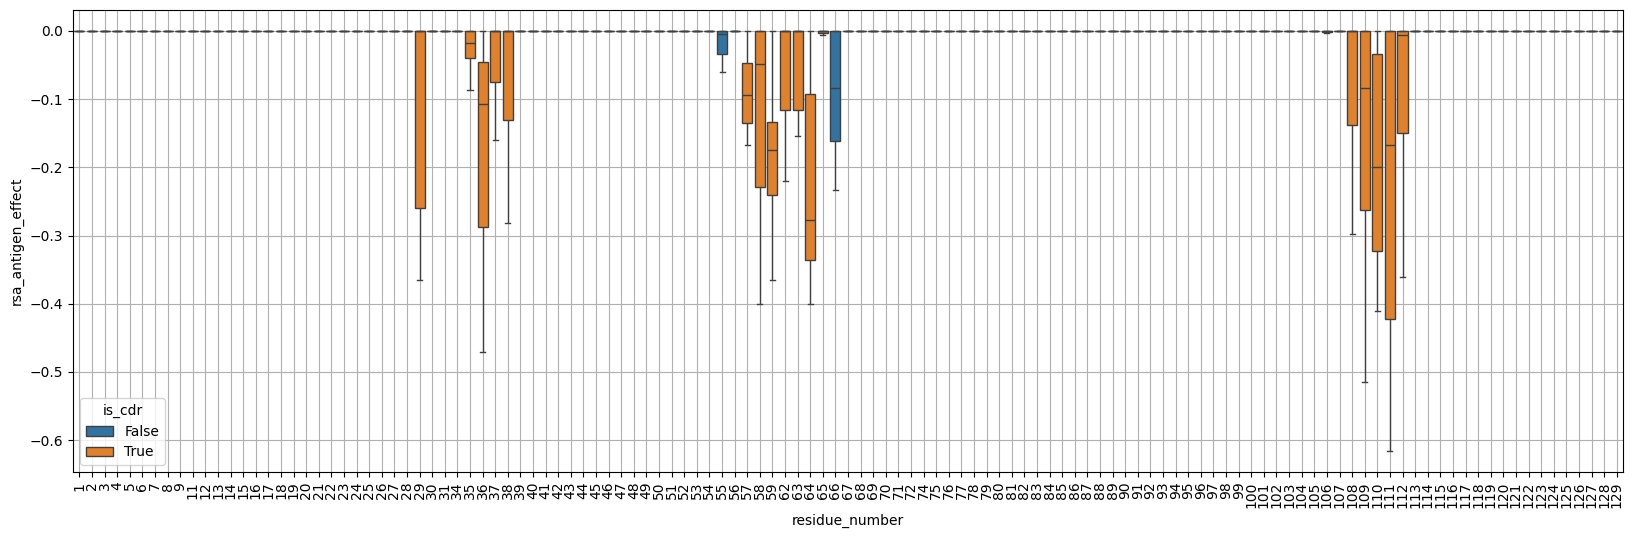

In [104]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.boxplot(df, x='residue_number', y='rsa_antigen_effect', ax=ax, showfliers=False, hue='is_cdr')
# rotate x labels for better readability
plt.xticks(rotation=90)
ax.grid()


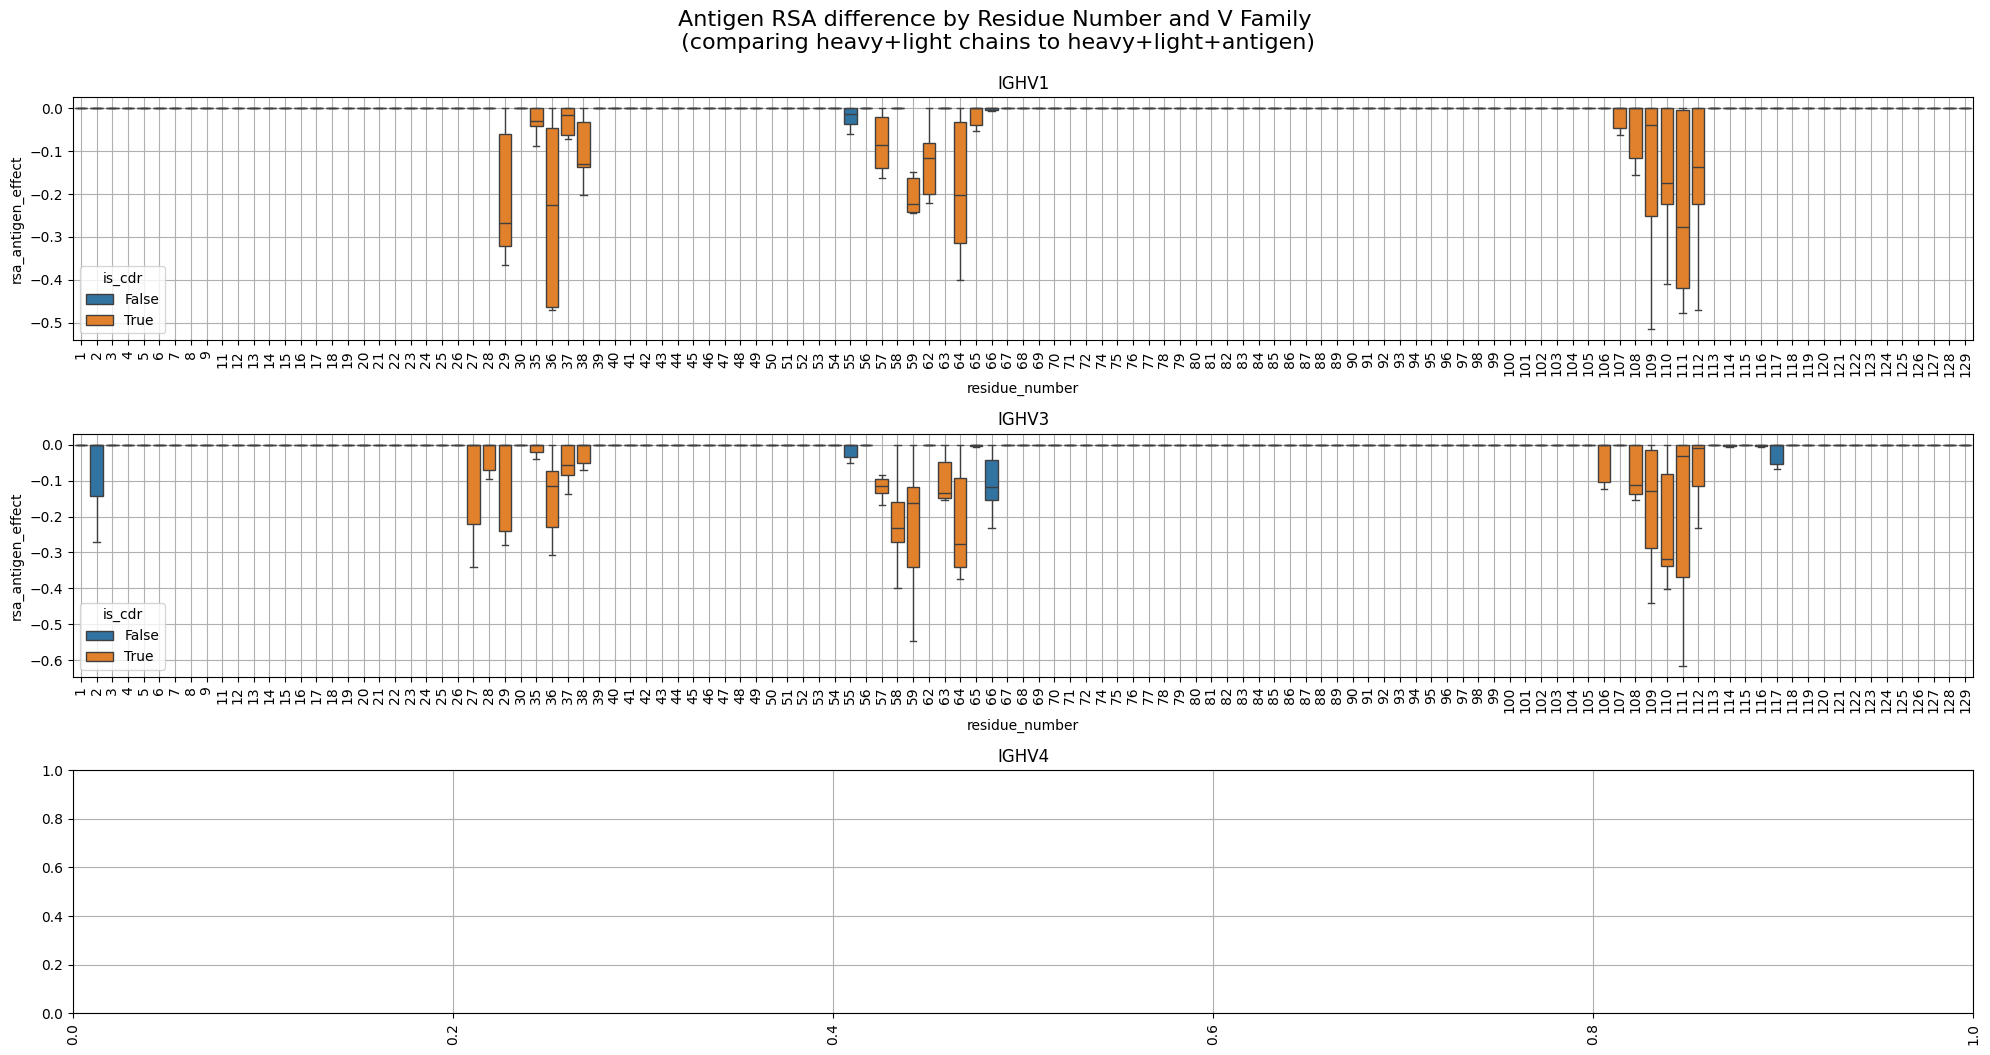

In [120]:
fig, axes = plt.subplots(3, 1, figsize=(20, 10))

# Define the gene types you want to plot
v_families = ['IGHV1', 'IGHV3', 'IGHV4']

for i, gene_type in enumerate(v_families):
    # Filter data for each gene type
    filtered_data = df[(df.v_family_heavy == gene_type)]
    
    # Create countplot for each subplot
    sns.boxplot(data=filtered_data, x='residue_number', y='rsa_antigen_effect', showfliers=False, ax=axes[i], hue='is_cdr')

    # Set title for each subplot
    axes[i].set_title(f'{gene_type}')
    
    # Rotate x labels for better readability
    axes[i].tick_params(axis='x', rotation=90)

    axes[i].grid()

# Adjust layout to prevent overlap
plt.tight_layout()
# set title for whole plot
plt.suptitle('Antigen RSA difference by Residue Number and V Family\n (comparing heavy+light chains to heavy+light+antigen)', fontsize=16, y=1.05)
plt.show()

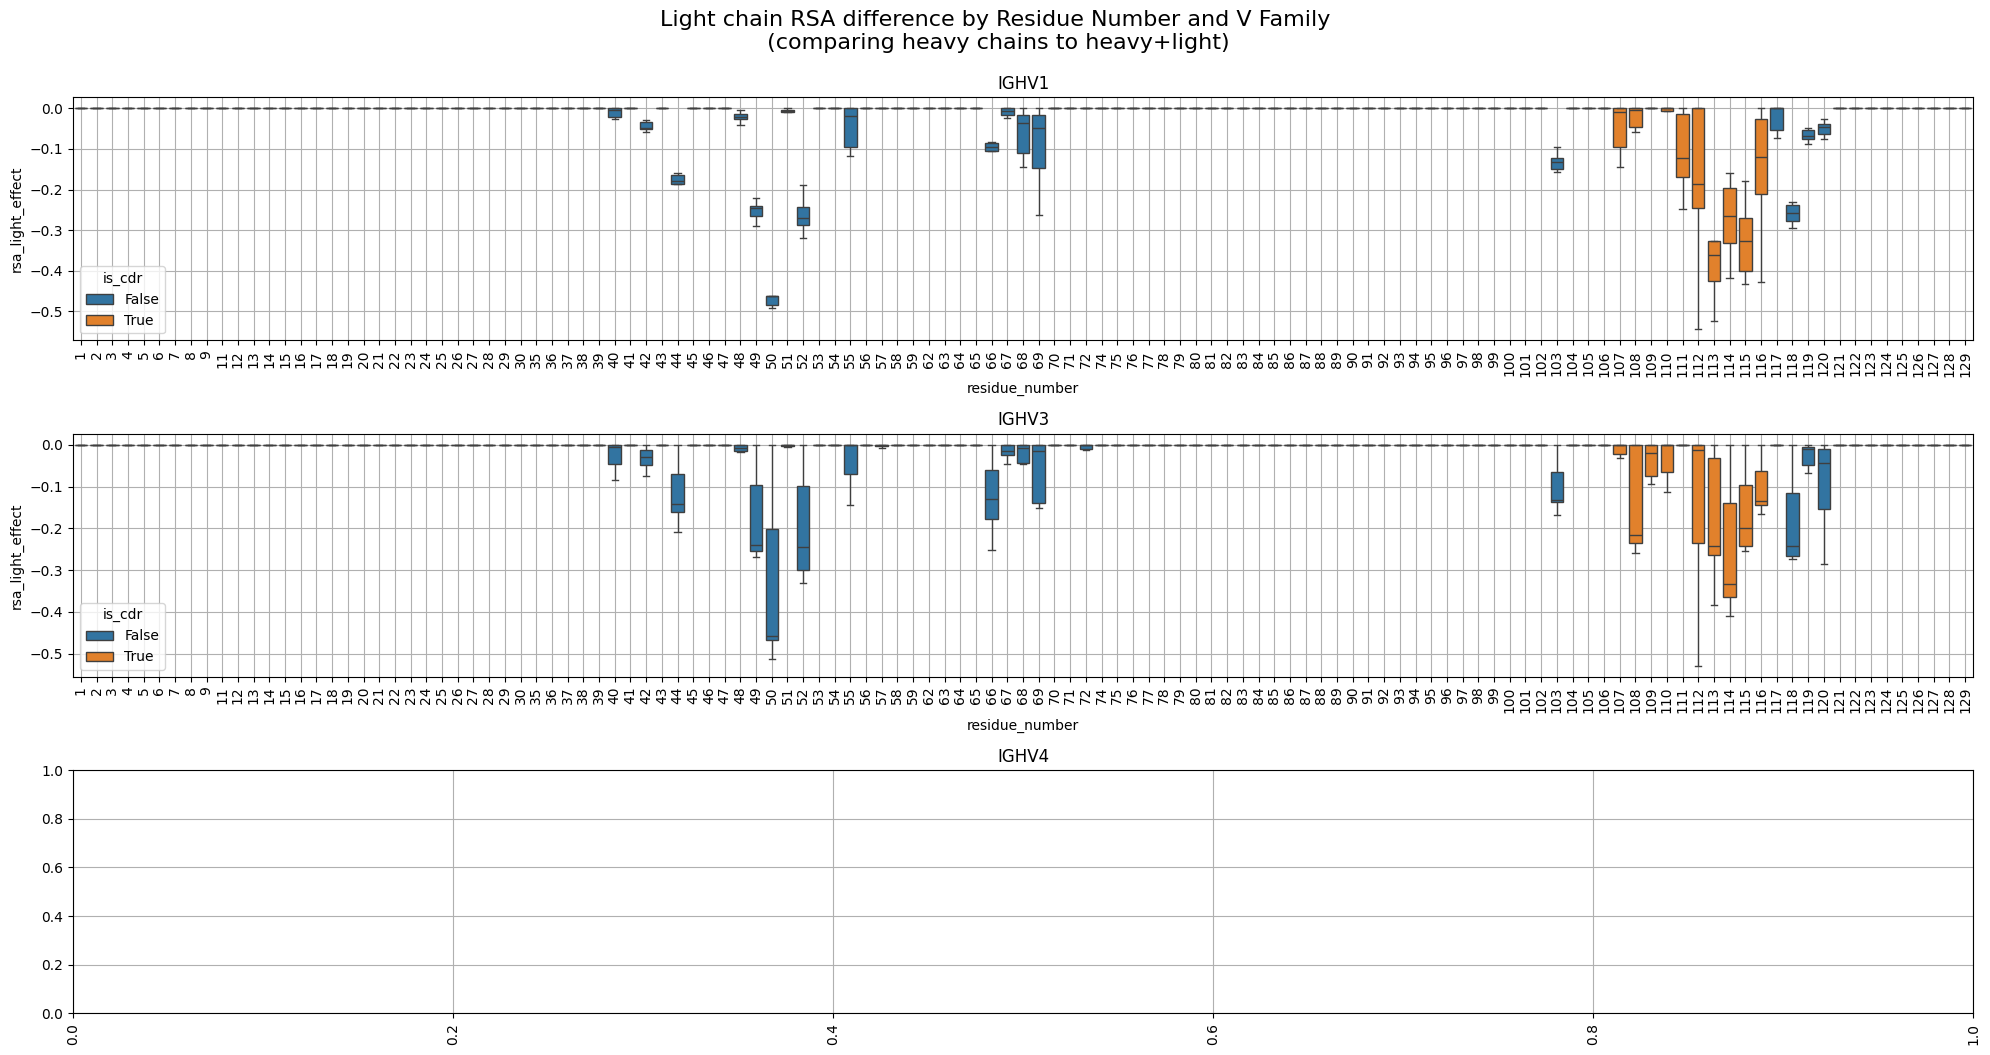

In [121]:
fig, axes = plt.subplots(3, 1, figsize=(20, 10))

# Define the gene types you want to plot
v_families = ['IGHV1', 'IGHV3', 'IGHV4']

for i, gene_type in enumerate(v_families):
    # Filter data for each gene type
    filtered_data = df[(df.v_family_heavy == gene_type)]
    
    # Create countplot for each subplot
    sns.boxplot(data=filtered_data, x='residue_number', y='rsa_light_effect', showfliers=False, ax=axes[i], hue='is_cdr')

    # Set title for each subplot
    axes[i].set_title(f'{gene_type}')
    
    # Rotate x labels for better readability
    axes[i].tick_params(axis='x', rotation=90)

    axes[i].grid()

# Adjust layout to prevent overlap
plt.tight_layout()
plt.suptitle('Light chain RSA difference by Residue Number and V Family\n (comparing heavy chains to heavy+light)', fontsize=16, y=1.05)

plt.show()

In [147]:
# IGHV3 deep dive    
df_v3 = df[(df.v_family_heavy == 'IGHV3')]
df_v4 = df[(df.v_family_heavy == 'IGHV4')]

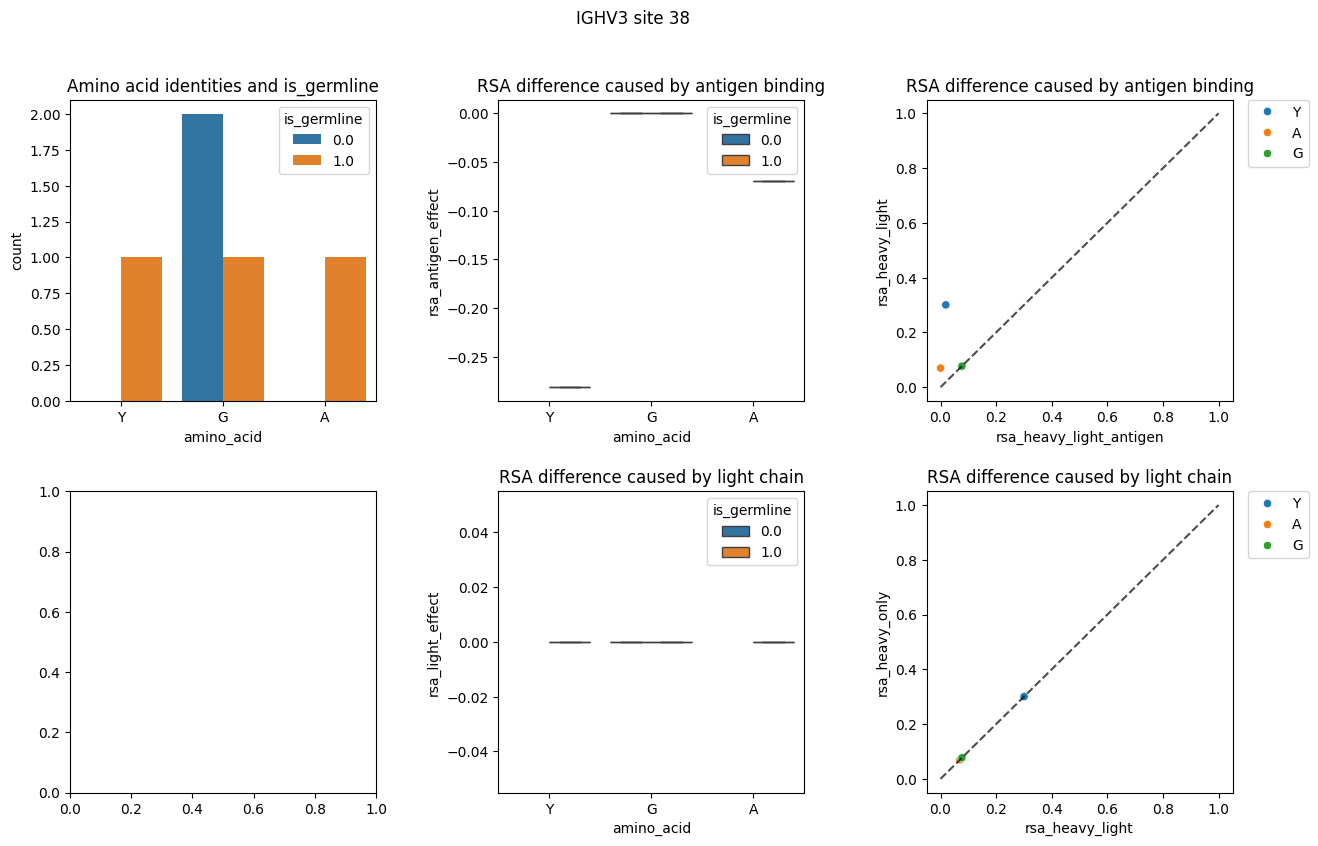

In [144]:
def examine_site(df_vfamily, site, suptitle):
    fig, ax = plt.subplots(2, 3, figsize=(15,9))
    ax = ax.flatten()
    fig.subplots_adjust(wspace=0.4, hspace=0.3)
    sns.countplot(df_vfamily[df_vfamily.residue_number == site], x='amino_acid', hue='is_germline', ax=ax[0])
    ax[0].set_title(f'Amino acid identities and is_germline')
    
    sns.boxplot(df_vfamily[df_vfamily.residue_number == site], x='amino_acid', y='rsa_antigen_effect', showfliers=False, hue='is_germline', ax=ax[1])
    ax[1].set_title(f'RSA difference caused by antigen binding')

    sns.scatterplot(df_vfamily[(df_vfamily.residue_number == site) & (df_vfamily.is_germline == True)], x='rsa_heavy_light_antigen', y='rsa_heavy_light', hue='amino_acid', ax=ax[2])
    ax[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    ax[2].plot([0, 1], [0, 1], 'k--', alpha=0.7)
    ax[2].set_title(f'RSA difference caused by antigen binding')

    sns.boxplot(df_vfamily[df_vfamily.residue_number == site], x='amino_acid', y='rsa_light_effect', showfliers=False, hue='is_germline', ax=ax[4])
    ax[4].set_title(f'RSA difference caused by light chain')

    
    sns.scatterplot(df_vfamily[(df_vfamily.residue_number == site) & (df_vfamily.is_germline == True)], x='rsa_heavy_light', y='rsa_heavy_only', hue='amino_acid', ax=ax[5])
    ax[5].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    ax[5].plot([0, 1], [0, 1], 'k--', alpha=0.7)
    ax[5].set_title(f'RSA difference caused by light chain')

    fig.suptitle(suptitle)
examine_site(df_v3, 38, 'IGHV3 site 38')


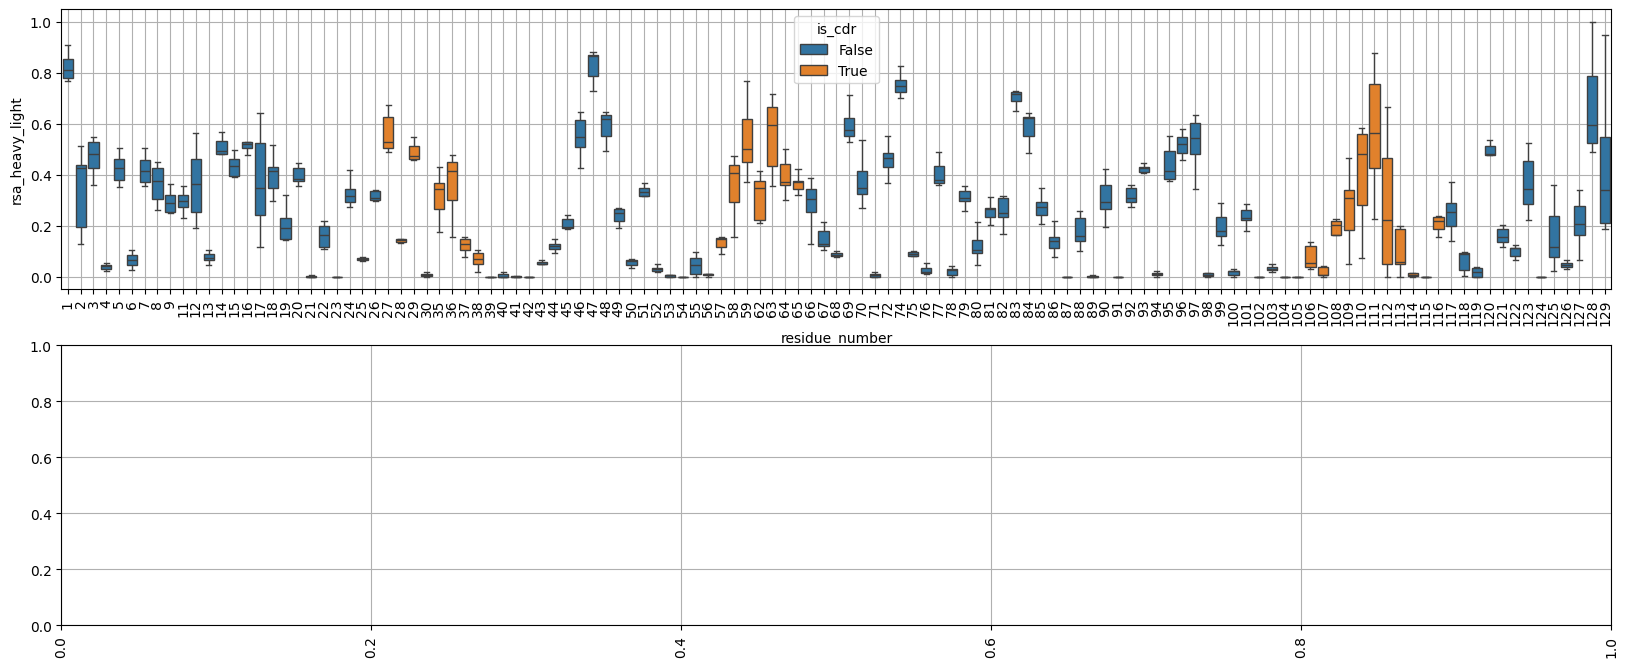

In [150]:
fig, axes = plt.subplots(2, 1, figsize=(20, 8))
sns.boxplot(df_v3, x='residue_number', y='rsa_heavy_light', ax=axes[0], showfliers=False, hue='is_cdr')
sns.boxplot(df_v4, x='residue_number', y='rsa_heavy_light', ax=axes[1], showfliers=False, hue='is_cdr')
for ax in axes:
    ax.tick_params(axis='x', rotation=90)
    ax.grid()


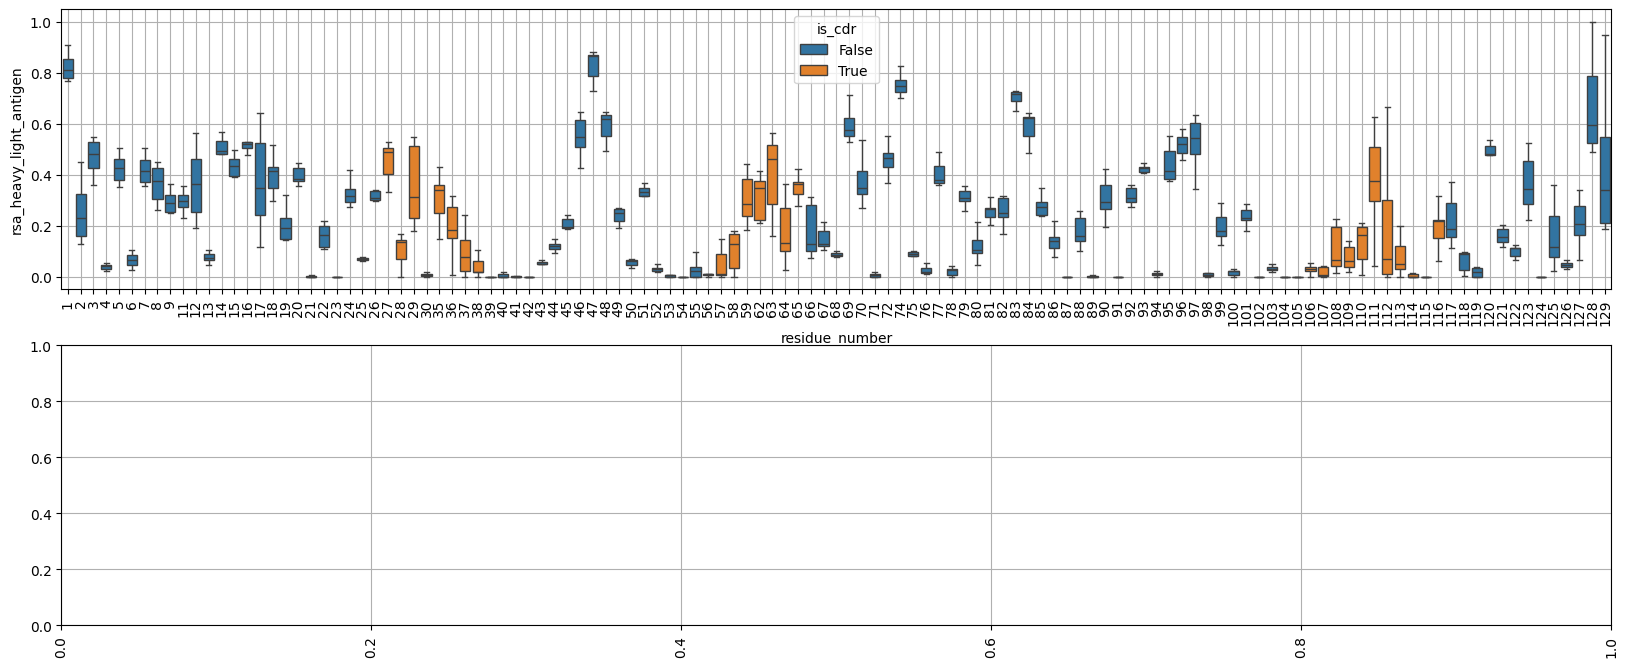

In [151]:
fig, axes = plt.subplots(2, 1, figsize=(20, 8))
sns.boxplot(df_v3, x='residue_number', y='rsa_heavy_light_antigen', ax=axes[0], showfliers=False, hue='is_cdr')
sns.boxplot(df_v4, x='residue_number', y='rsa_heavy_light_antigen', ax=axes[1], showfliers=False, hue='is_cdr')
for ax in axes:
    ax.tick_params(axis='x', rotation=90)
    ax.grid()


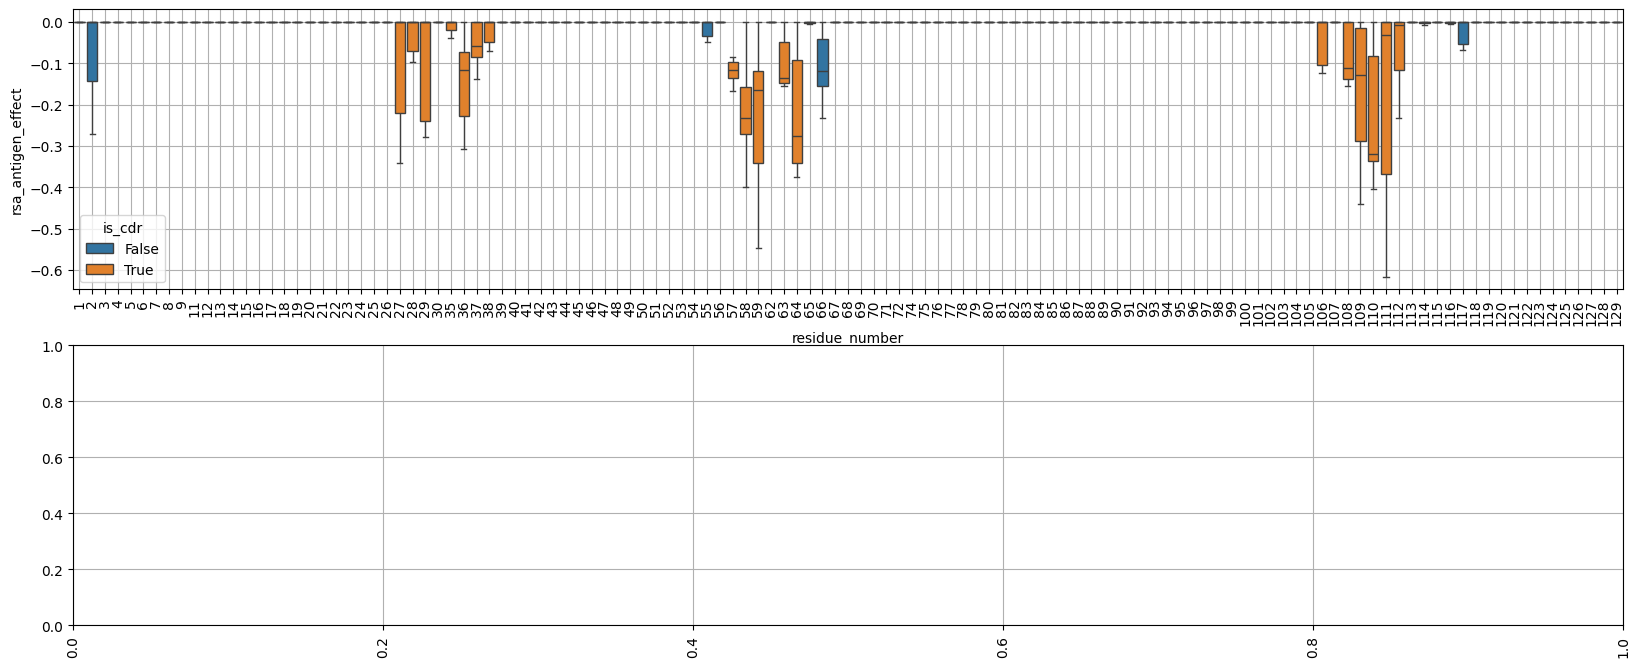

In [152]:
fig, axes = plt.subplots(2, 1, figsize=(20, 8))
sns.boxplot(df_v3, x='residue_number', y='rsa_antigen_effect', ax=axes[0], showfliers=False, hue='is_cdr')
sns.boxplot(df_v4, x='residue_number', y='rsa_antigen_effect', ax=axes[1], showfliers=False, hue='is_cdr')
for ax in axes:
    ax.tick_params(axis='x', rotation=90)
    ax.grid()


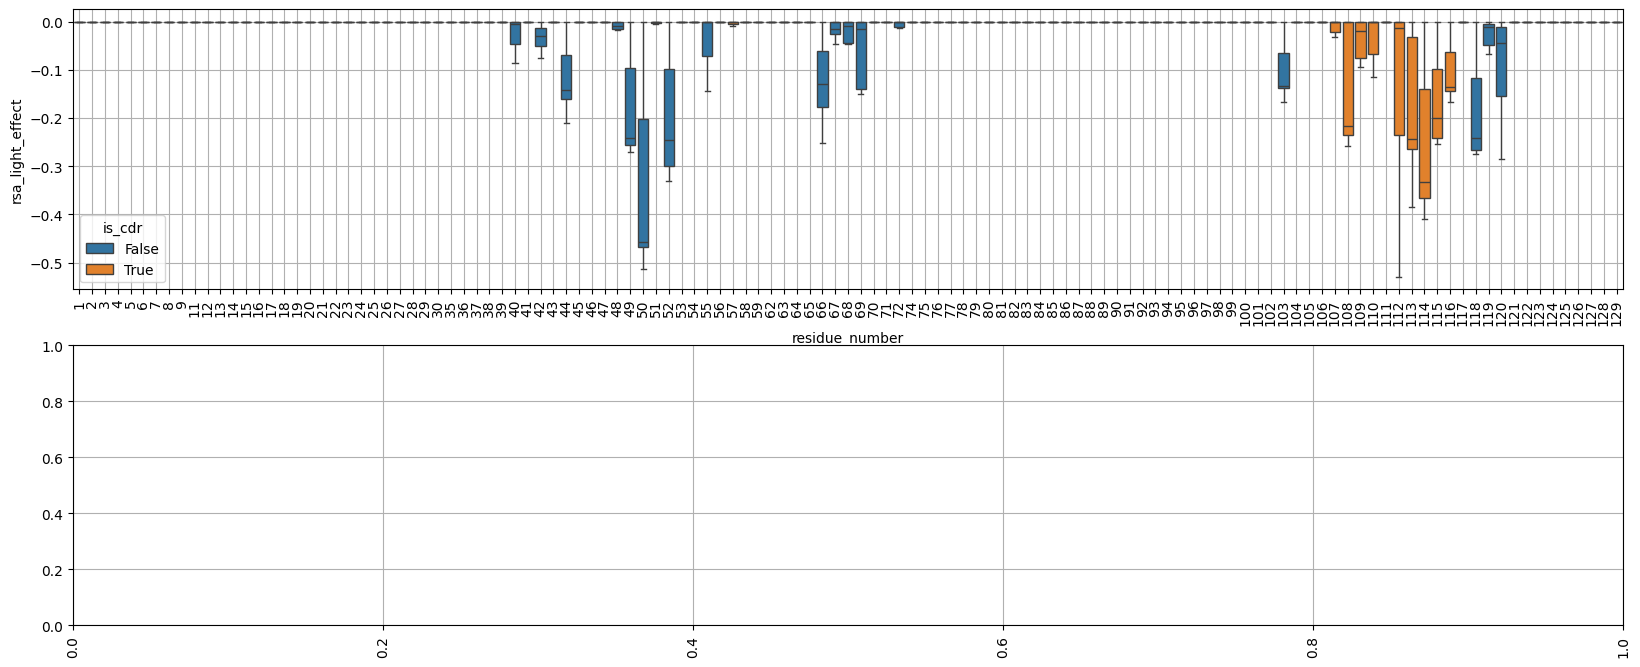

In [153]:
fig, axes = plt.subplots(2, 1, figsize=(20, 8))
sns.boxplot(df_v3, x='residue_number', y='rsa_light_effect', ax=axes[0], showfliers=False, hue='is_cdr')
sns.boxplot(df_v4, x='residue_number', y='rsa_light_effect', ax=axes[1], showfliers=False, hue='is_cdr')
for ax in axes:
    ax.tick_params(axis='x', rotation=90)
    ax.grid()
